In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.shape

(8807, 12)

In [4]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [6]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['director']=df['director'].fillna('Unknown')

In [10]:
df['director'].isnull().sum()

np.int64(0)

In [12]:
df['cast'].isnull().sum()

np.int64(825)

In [15]:
df['cast']=df['cast'].fillna('Unknown')

In [16]:
df['country']=df['country'].fillna('Unknown')

In [17]:
df['date_added']=df['date_added'].fillna('Unknown')

In [18]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          4
duration        3
listed_in       0
description     0
dtype: int64

In [19]:
df['rating']=df['rating'].fillna('Unknown')

In [20]:
df['duration']=df['duration'].fillna('Unknown')

In [21]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [26]:
df['date_added'].isnull().sum()

np.int64(0)

In [28]:
df['date_added'] = pd.to_datetime(df['date_added'],errors='coerce')


In [29]:
df['year_added']=df['date_added'].dt.year

In [30]:
df['month_added']=df['date_added'].dt.month

In [33]:
df['date_added']=pd.to_datetime(df['date_added'])

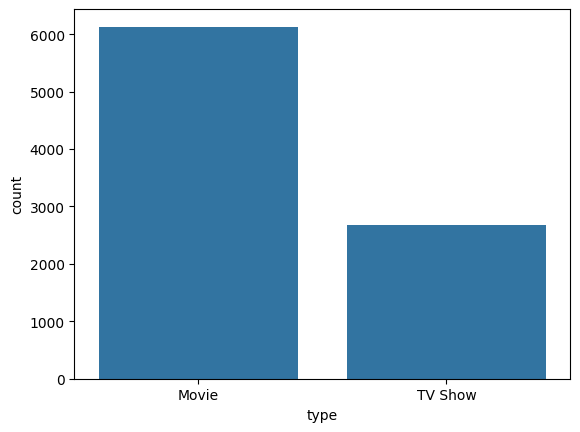

In [34]:
sns.countplot(x='type',data=df)
plt.show()

In [35]:
df['type'].value_counts(normalize=True)*100

type
Movie      69.615079
TV Show    30.384921
Name: proportion, dtype: float64

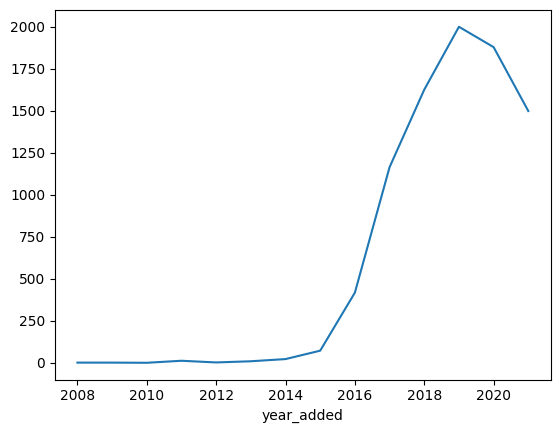

In [36]:
df['year_added'].value_counts().sort_index().plot()
plt.show()

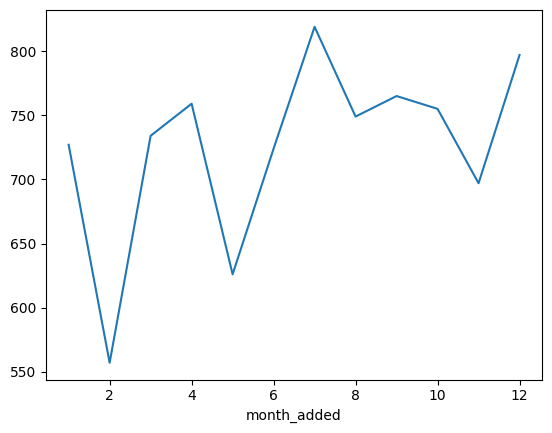

In [37]:
df['month_added'].value_counts().sort_index().plot()
plt.show()

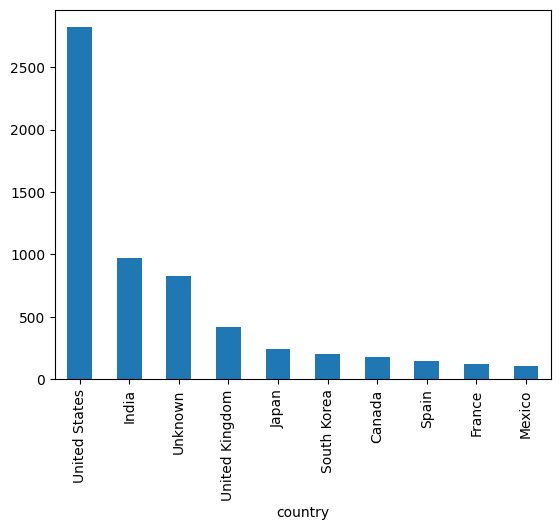

In [38]:
top=df['country'].value_counts().head(10)
top.plot(kind='bar')
plt.show()

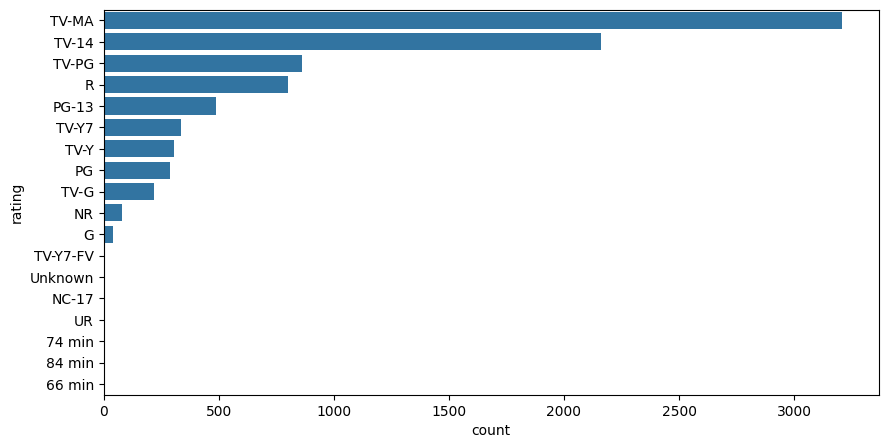

In [39]:
plt.figure(figsize=(10,5))
sns.countplot(y='rating',data=df,order=df['rating'].value_counts().index)
plt.show()

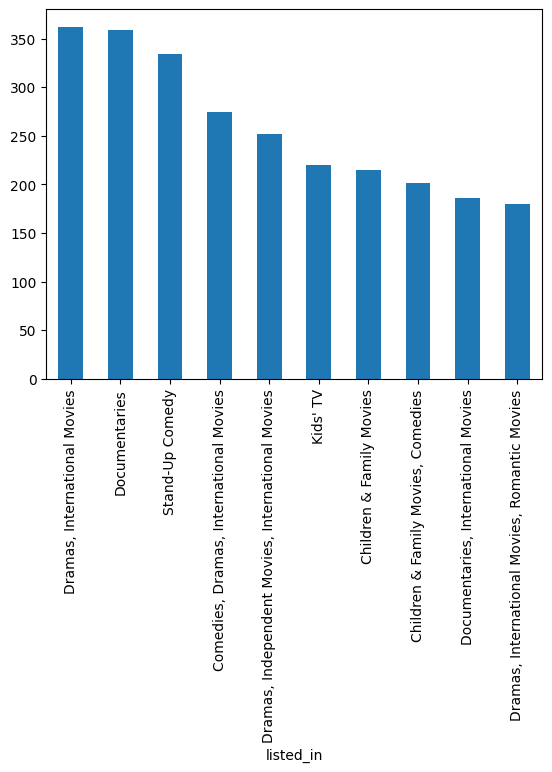

In [43]:
top=df['listed_in'].value_counts().head(10)
top.plot(kind='bar')
plt.show()

In [50]:
movies = df[df["type"] == "Movie"]

In [54]:
movies['duration_num'] = movies[
'duration'
].str.replace(
' min',
'',
regex=False
)

In [55]:
movies['duration_num'] = pd.to_numeric(
movies['duration_num'],
errors='coerce'
)

In [56]:
movies[
['duration','duration_num']
].head()

,duration,duration_num
0,90 min,90.0
6,91 min,91.0
7,125 min,125.0
9,104 min,104.0
12,127 min,127.0


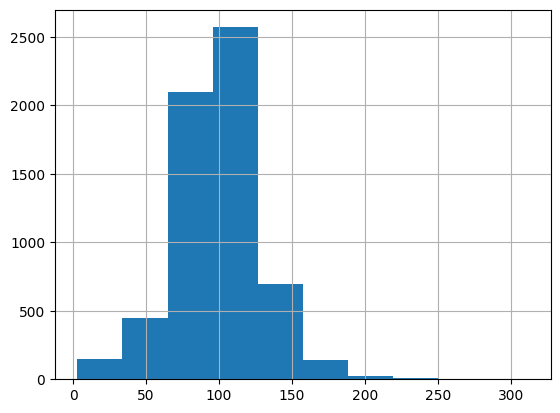

In [57]:
movies['duration_num'].hist()

plt.show()

In [59]:
df['director'].value_counts().head(10)

director
Unknown                   2634
Rajiv Chilaka               19
Raúl Campos, Jan Suter      18
Suhas Kadav                 16
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
Youssef Chahine             12
Martin Scorsese             12
Jay Chapman                 12
Name: count, dtype: int64

In [61]:
df['cast'].value_counts().head(10)

cast
Unknown                                                                                                                   825
David Attenborough                                                                                                         19
Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jigna Bhardwaj, Rajesh Kava, Mousam, Swapnil                                    14
Samuel West                                                                                                                10
Jeff Dunham                                                                                                                 7
David Spade, London Hughes, Fortune Feimster                                                                                6
Kevin Hart                                                                                                                  6
Michela Luci, Jamie Watson, Eric Peterson, Anna Claire Bartlam, Nicolas Aqui, Cory Doran, Julie Lemieux, Derek Mc

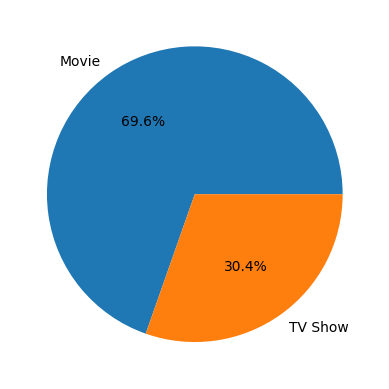

In [62]:
df['type'].value_counts().plot(
kind='pie',
autopct='%1.1f%%'
)

plt.ylabel('')

plt.show()

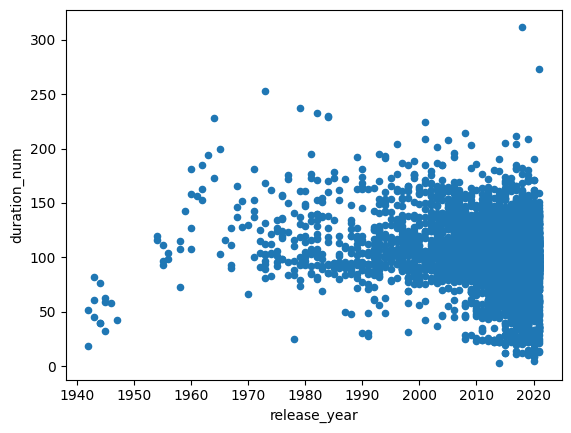

In [63]:
movies.plot.scatter(
x='release_year',
y='duration_num'
)

plt.show()

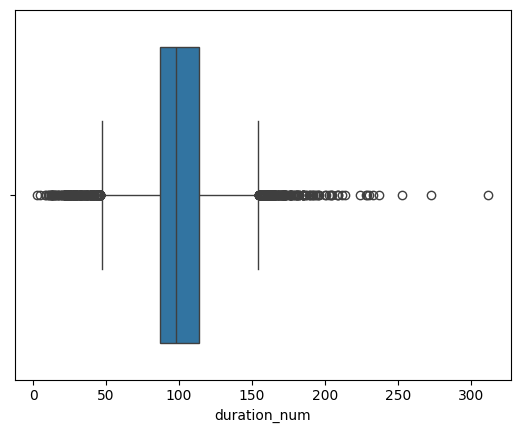

In [64]:
sns.boxplot(
x=movies[
'duration_num'
]
)

plt.show()

# Insights

• Netflix content catalog is dominated by movies, with movies accounting for a significantly larger share compared to TV shows.

• Netflix content additions increased rapidly after 2015, indicating strong platform expansion and content investment.

• Content additions reached peak levels around 2019–2020, followed by a slight decline in later years.

• The United States contributes the highest amount of content on Netflix, followed by other major content-producing countries.

• International content production has increased significantly, indicating Netflix's focus on global expansion.

• International Movies, Documentaries, and Comedy categories appear more frequently compared to other genres.

• TV-MA and TV-14 ratings dominate the platform, suggesting Netflix primarily targets mature and young adult audiences.

• Most movie durations fall between approximately 80–120 minutes, indicating medium-length movies dominate the platform.

• Duration analysis shows the presence of several outliers, suggesting Netflix also hosts extremely long-duration movies.

• Scatter plot analysis indicates no strong relationship between release year and movie duration.

• Monthly content additions vary throughout the year, with certain months experiencing relatively higher content releases.

• Overall analysis suggests Netflix focuses on movie-heavy content distribution, global expansion, diversified content categories, and mature audience targeting.
